In [ ]:
!pip install pandas_datareader
!pip install yfinance #yahoo finance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf # yahoo finance
from pandas_datareader import data as pdr #pandas reader
yf.pdr_override() #many stock data

In [ ]:
data = yf.download(tickers, start_date)
missing = list(yf.shared._ERRORS.keys())

In [6]:
data=pdr.get_data_yahoo("005930.KS",start="2021-01-01",end="2022-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,81000.0,84400.0,80200.0,83000.0,79093.812500,38655276
2021-01-05,81600.0,83900.0,81600.0,83900.0,79951.445312,35335669
2021-01-06,83300.0,84500.0,82100.0,82200.0,78331.453125,42089013
2021-01-07,82800.0,84200.0,82700.0,82900.0,78998.515625,32644642
2021-01-08,83300.0,90000.0,83000.0,88800.0,84620.843750,59013307


In [7]:
Op=np.array(data["Open"])
Hi=np.array(data["High"])
Lo=np.array(data["Low"])
Cl=np.array(data["Close"])
Adj=np.array(data["Adj Close"])
V=np.array(data["Volume"])

In [8]:
input=np.column_stack((Op,Hi,Lo,Cl, V)) 
output=Adj

In [9]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
input_scaled=SS.fit_transform(input)

In [16]:
print(input_scaled[0:5, :])

[[0.36444355 0.90580045 0.34742273 0.79813712 2.09079108]
 [0.48994506 0.80487561 0.64540981 0.9849886  1.74150909]
 [0.84553266 0.92598542 0.75183376 0.63204691 2.45208159]
 [0.74094807 0.86543051 0.87954251 0.77737584 1.45836495]
 [0.84553266 2.03615867 0.94339689 2.00229112 4.23281983]]


In [18]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_output,test_output=train_test_split(input_scaled,output)

In [21]:
from xgboost import XGBRegressor, XGBClassifier, plot_importance

In [22]:
XGBR = XGBRegressor(max_depth=3, reg_lambda=0.1) #L2 #reg_alpha=5 (L1)
#XGBR = XGBClassifier(max_depth=3, reg_alpha=0.1) #L2 #reg_alpha=5 (L1)

In [23]:
XGBR.fit(train_input,train_output)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [24]:
XGBR.score(test_input,test_output)

0.9916445852516753

In [25]:
np.corrcoef(XGBR.predict(test_input),test_output)

array([[1.        , 0.99633051],
       [0.99633051, 1.        ]])

[Text(0, 0, 'Open'),
 Text(0, 1, 'High'),
 Text(0, 2, 'Low'),
 Text(0, 3, 'Close'),
 Text(0, 4, 'Volume')]

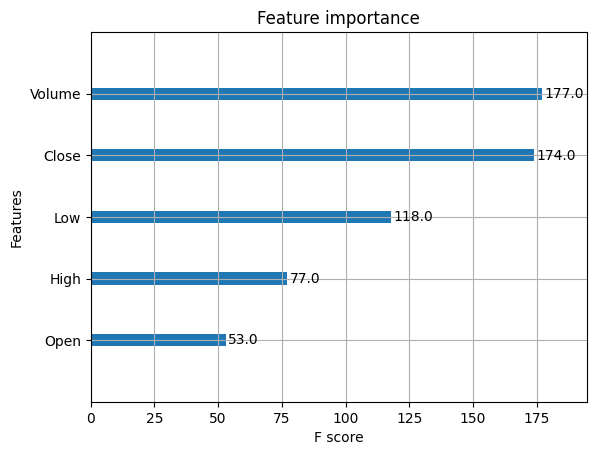

In [26]:
plot_importance(XGBR).set_yticklabels(["Open", "High", "Low", "Close","Volume"])

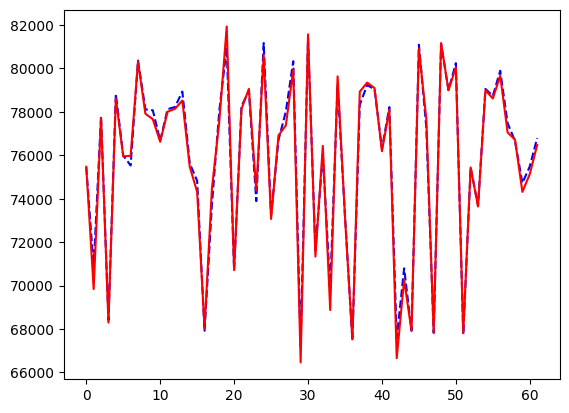

In [27]:
plt.plot(XGBR.predict(test_input),'b--')
plt.plot(test_output,'r')

In [ ]:
input2=np.column_stack((Op,Hi,Lo,Cl)) 
output2=Adj

In [ ]:
XGBR2=XGBClassifier(max_depth=3, reg_alpha=0.1) #L2 #reg_alpha=5 (L1)

In [ ]:
from sklearn.model_selection import train_test_split
train_input2,test_input2,train_output2,test_output2=train_test_split(input2,output2)

In [ ]:
XGBR2.fit(train_input2,train_output2)

XGBClassifier(objective='multi:softprob', reg_alpha=0.1)

In [ ]:
np.corrcoef(XGBR2.predict(test_input2),test_output2)

array([[1.        , 0.96738476],
       [0.96738476, 1.        ]])

[Text(0, 0, 'Open'),
 Text(0, 0, 'High'),
 Text(0, 0, 'Low'),
 Text(0, 0, 'Close')]

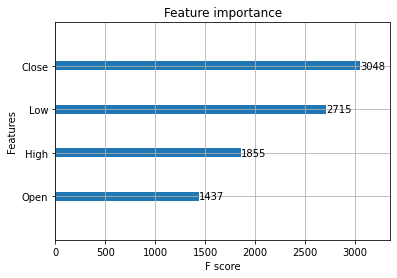

In [ ]:
plot_importance(XGBR2).set_yticklabels(["Open", "High", "Low", "Close"])

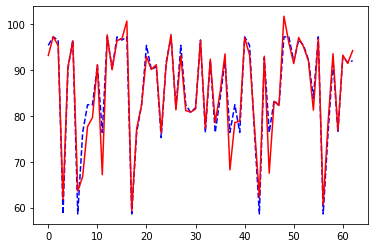

In [ ]:
plt.plot(XGBR2.predict(test_input2),'b--')
plt.plot(test_output2,'r')